In [26]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# STEP 1: Get all CSV files from analysis_data folder
# ------------------------------------------------------------
folder_path = "analysis_data"
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"  - {f}")

# ------------------------------------------------------------
# STEP 2: Read each CSV and create a dataframe
# ------------------------------------------------------------
dfs_to_merge = []

for csv_file in csv_files:
    # Read the CSV
    file_path = os.path.join(folder_path, csv_file)
    df = pd.read_csv(file_path)
    
    # Get column name from filename (remove .csv extension)
    column_name = Path(csv_file).stem
    
    # Rename 'score' column to the filename
    df = df.rename(columns={"score": column_name})
    
    # Keep only group_name and the score column
    df = df[["group_name", column_name]]
    
    dfs_to_merge.append(df)

# ------------------------------------------------------------
# STEP 3: Merge all dataframes on group_name
# ------------------------------------------------------------
# Start with the first dataframe
result_df = dfs_to_merge[0]

# Merge each subsequent dataframe
for df in dfs_to_merge[1:]:
    result_df = result_df.merge(df, on="group_name", how="outer")

# Sort by group_name for easier reading
result_df = result_df.sort_values("group_name").reset_index(drop=True)

# Fill any missing values with 0
result_df = result_df.fillna(0)

# ------------------------------------------------------------
# STEP 4: Create final_score column (sum across all scores)
# ------------------------------------------------------------
# Get all columns except group_name
score_columns = [col for col in result_df.columns if col != "group_name"]

# Sum across all score columns
result_df["final_score"] = result_df[score_columns].sum(axis=1)

# Sort by final_score (highest to lowest)
result_df = result_df.sort_values("final_score", ascending=False).reset_index(drop=True)

result_df

Found 8 CSV files:
  - target.csv
  - predictions.csv
  - origin.csv
  - industries.csv
  - novelty.csv
  - motivations.csv
  - diversity.csv
  - defense.csv


,group_name,target,predictions,origin,industries,novelty,motivations,diversity,defense,final_score
0,Lazarus Group,0.878320,0.858381,0.709335,0.531144,0.230398,0.571429,0.989905,0.96,5.728911
1,Mustang Panda,0.587193,0.776092,0.675963,0.664971,0.318380,0.896104,0.930103,0.72,5.568806
2,Magic Hound,0.858414,0.728223,1.000000,0.469475,0.197251,0.714286,0.991649,0.60,5.559298
3,Kimsuky,0.668481,1.000000,0.648295,0.316517,0.250318,0.571429,0.990614,0.88,5.325653
4,APT39,0.643698,0.475383,0.675838,0.849169,0.174896,1.000000,0.874613,0.44,5.133596
...,...,...,...,...,...,...,...,...,...,...
182,MONSOON,0.000000,0.000000,0.000000,0.843753,0.000000,0.000000,0.000000,0.00,0.843753
183,Stolen Pencil,0.000000,0.000000,0.000000,0.843753,0.000000,0.000000,0.000000,0.00,0.843753
184,Sharpshooter,0.000000,0.000000,0.000000,0.843753,0.000000,0.000000,0.000000,0.00,0.843753
185,Taidoor,0.000000,0.000000,0.000000,0.843753,0.000000,0.000000,0.000000,0.00,0.843753


In [27]:
result_df.head(20)

,group_name,target,predictions,origin,industries,novelty,motivations,diversity,defense,final_score
0,Lazarus Group,0.878320,0.858381,0.709335,0.531144,0.230398,0.571429,0.989905,0.96,5.728911
1,Mustang Panda,0.587193,0.776092,0.675963,0.664971,0.318380,0.896104,0.930103,0.72,5.568806
2,Magic Hound,0.858414,0.728223,1.000000,0.469475,0.197251,0.714286,0.991649,0.60,5.559298
3,Kimsuky,0.668481,1.000000,0.648295,0.316517,0.250318,0.571429,0.990614,0.88,5.325653
4,APT39,0.643698,0.475383,0.675838,0.849169,0.174896,1.000000,0.874613,0.44,5.133596
5,FIN7,0.954720,0.612435,0.852585,0.283357,0.190054,0.714286,0.988545,0.52,5.115982
6,Turla,0.700721,0.624503,0.781946,0.502870,0.249172,0.571429,0.865034,0.68,4.975675
7,Scattered Spider,1.000000,0.600852,0.880365,0.073233,0.379517,0.714286,0.996743,0.32,4.964995
8,BlackByte,0.869320,0.451264,0.928090,0.569519,0.158439,0.714286,0.924422,0.32,4.935340
9,Volt Typhoon,0.683344,0.753235,0.780716,0.555179,0.292678,0.000000,0.865946,1.00,4.931097


In [28]:
# ------------------------------------------------------------
# Create final_unequal_weighting_score (weighted sum)
# ------------------------------------------------------------

mot_col = "motivations"                         # the special column
other_cols = [c for c in score_columns if c != mot_col]

w_mot = 0.0625                                   # 6.25%
w_other = (1 - w_mot) / len(other_cols)          # equal weight for remaining 7

result_df["final_unequal_weighting_score"] = (
    result_df[mot_col] * w_mot +
    result_df[other_cols].sum(axis=1) * w_other
)


In [29]:
result_df = result_df.sort_values("final_unequal_weighting_score", ascending=False).reset_index(drop=True)

In [30]:
result_df.head(10)

,group_name,target,predictions,origin,industries,novelty,motivations,diversity,defense,final_score,final_unequal_weighting_score
0,Lazarus Group,0.878320,0.858381,0.709335,0.531144,0.230398,0.571429,0.989905,0.96,5.728911,0.726449
1,Magic Hound,0.858414,0.728223,1.000000,0.469475,0.197251,0.714286,0.991649,0.60,5.559298,0.693528
2,Mustang Panda,0.587193,0.776092,0.675963,0.664971,0.318380,0.896104,0.930103,0.72,5.568806,0.681815
3,Kimsuky,0.668481,1.000000,0.648295,0.316517,0.250318,0.571429,0.990614,0.88,5.325653,0.672441
4,Volt Typhoon,0.683344,0.753235,0.780716,0.555179,0.292678,0.000000,0.865946,1.00,4.931097,0.660415
5,FIN7,0.954720,0.612435,0.852585,0.283357,0.190054,0.714286,0.988545,0.52,5.115982,0.634156
6,APT28,0.682952,0.835831,0.764033,0.520428,0.360630,0.000000,0.995620,0.56,4.719493,0.632075
7,Turla,0.700721,0.624503,0.781946,0.502870,0.249172,0.571429,0.865034,0.68,4.975675,0.625569
8,APT39,0.643698,0.475383,0.675838,0.849169,0.174896,1.000000,0.874613,0.44,5.133596,0.616107
9,Scattered Spider,1.000000,0.600852,0.880365,0.073233,0.379517,0.714286,0.996743,0.32,4.964995,0.613934


In [31]:
result_df[['group_name', 'novelty', 'motivations', 'defense', 'predictions', 'industries', 'origin', 'diversity', 'target', 'final_unequal_weighting_score']].head(10)

,group_name,novelty,motivations,defense,predictions,industries,origin,diversity,target,final_unequal_weighting_score
0,Lazarus Group,0.230398,0.571429,0.96,0.858381,0.531144,0.709335,0.989905,0.878320,0.726449
1,Magic Hound,0.197251,0.714286,0.60,0.728223,0.469475,1.000000,0.991649,0.858414,0.693528
2,Mustang Panda,0.318380,0.896104,0.72,0.776092,0.664971,0.675963,0.930103,0.587193,0.681815
3,Kimsuky,0.250318,0.571429,0.88,1.000000,0.316517,0.648295,0.990614,0.668481,0.672441
4,Volt Typhoon,0.292678,0.000000,1.00,0.753235,0.555179,0.780716,0.865946,0.683344,0.660415
5,FIN7,0.190054,0.714286,0.52,0.612435,0.283357,0.852585,0.988545,0.954720,0.634156
6,APT28,0.360630,0.000000,0.56,0.835831,0.520428,0.764033,0.995620,0.682952,0.632075
7,Turla,0.249172,0.571429,0.68,0.624503,0.502870,0.781946,0.865034,0.700721,0.625569
8,APT39,0.174896,1.000000,0.44,0.475383,0.849169,0.675838,0.874613,0.643698,0.616107
9,Scattered Spider,0.379517,0.714286,0.32,0.600852,0.073233,0.880365,0.996743,1.000000,0.613934


In [34]:
# Create a radar chart for an APT
def plot_apt_radar(df, group_name, metrics=None):
    if metrics is None:
        metrics = [
            "origin", "industries", "motivations",
            "predictions", "diversity",
            "novelty", "target", "defense"
        ]
    
    apt = df[df["group_name"] == group_name].iloc[0]
    values = apt[metrics].values.astype(float)
    values = np.append(values, values[0])  # close chart
    
    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
    angles = np.append(angles, angles[0])
    
    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.3)
    
    ax.set_thetagrids(angles[:-1] * 180/np.pi, metrics)
    ax.set_title(f"APT Radar Chart: {group_name}", fontsize=14)
    ax.set_ylim(0, 1)
    
    plt.show()


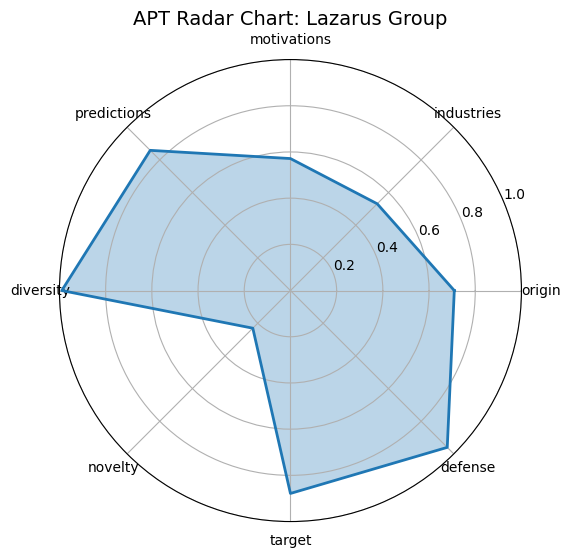

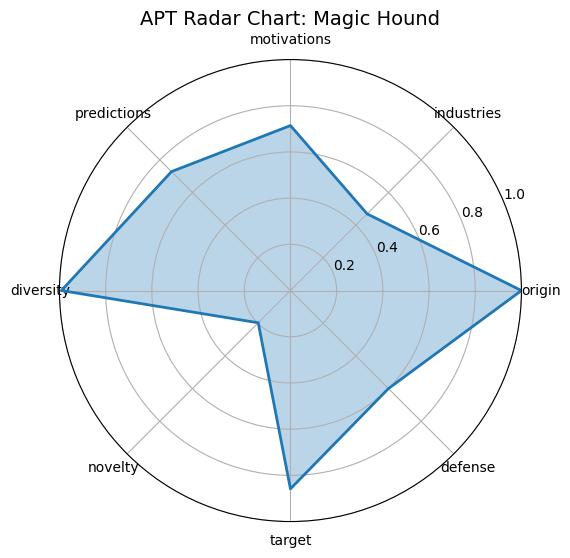

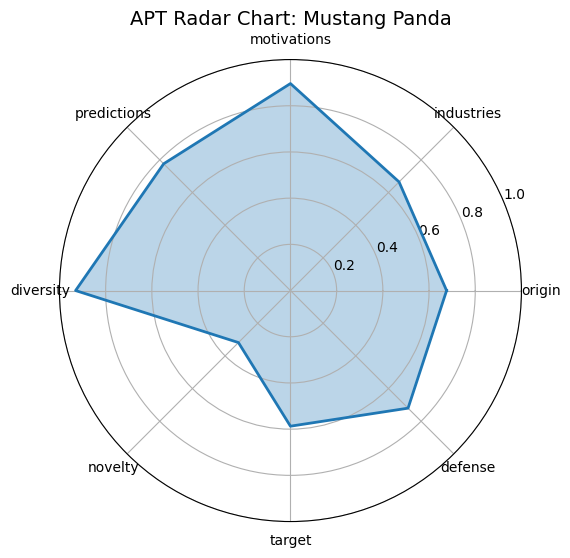

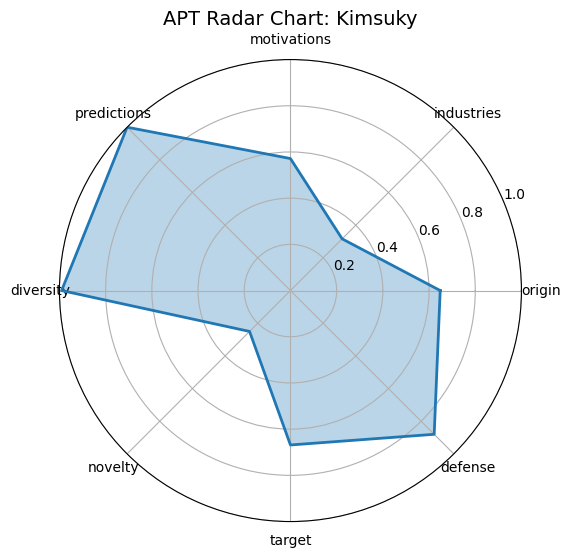

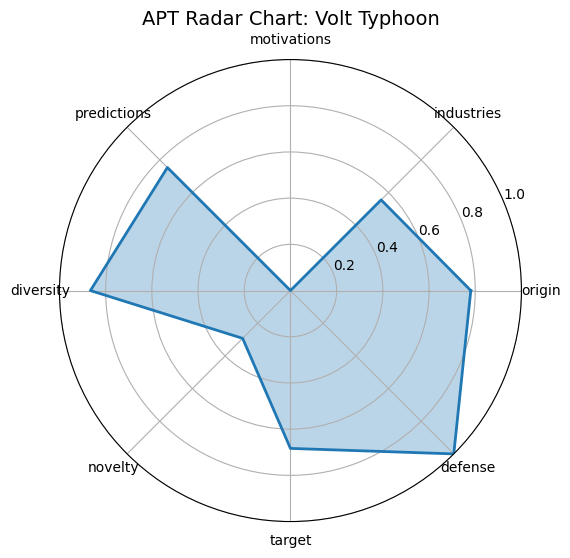

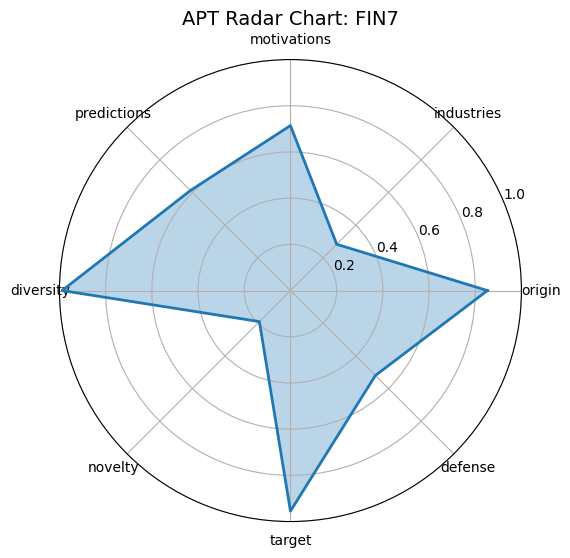

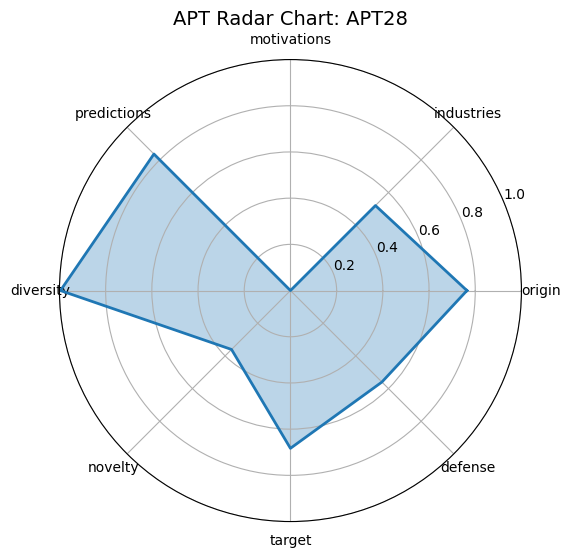

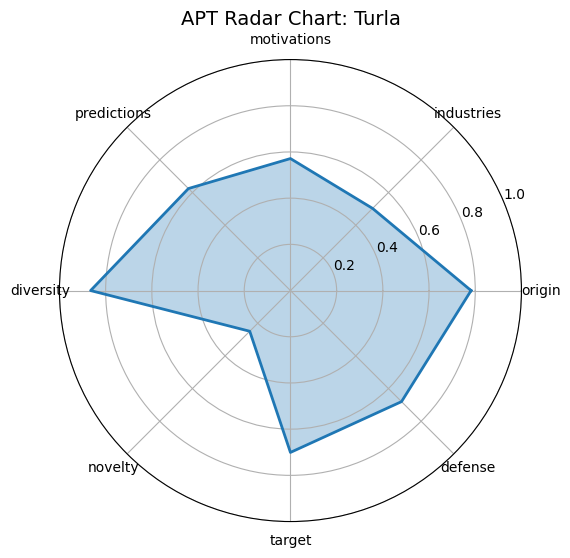

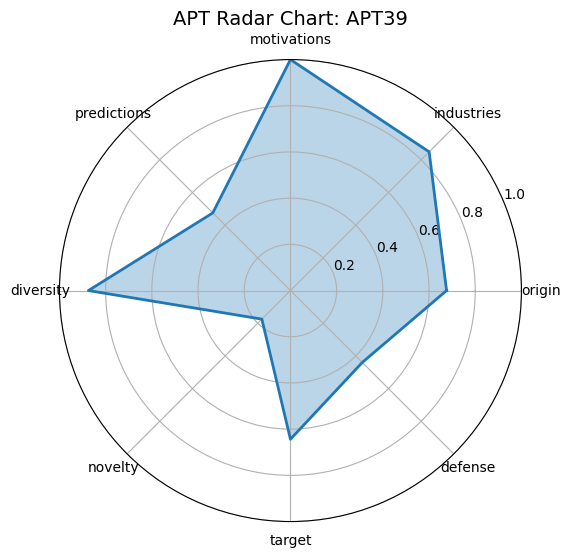

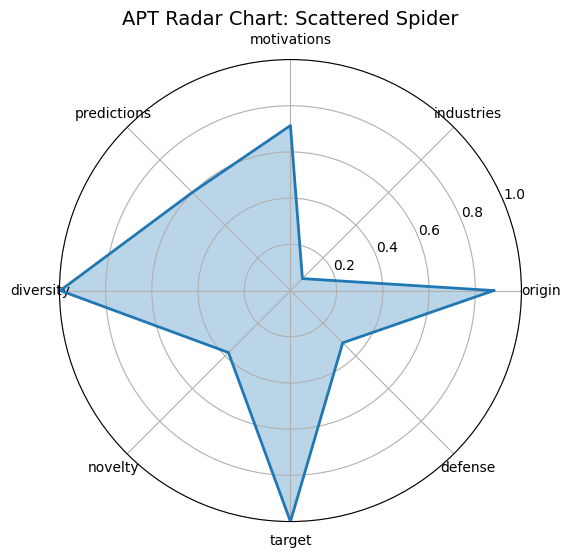

In [36]:
top_df = result_df.sort_values("final_unequal_weighting_score", ascending=False).head(10)

for group in top_df["group_name"]:
    plot_apt_radar(result_df, group)


Defenses

In [38]:
group_techniques_df

,group_id,group_name,technique_id,technique_name,tactic,technique_description,relationship_description
0,intrusion-set--01e28736-2ffc-455b-9880-ed4d140...,Indrik Spider,attack-pattern--65f2d882-3f41-4d48-8a06-29af77...,LSASS Memory,[credential-access],Adversaries may attempt to access credential m...,[Indrik Spider](https://attack.mitre.org/group...
1,intrusion-set--b7f627e2-0817-4cd5-8d50-e75f8aa...,LuminousMoth,attack-pattern--10ffac09-e42d-4f56-ab20-db94c6...,Steal Web Session Cookie,[credential-access],An adversary may steal web application or serv...,[LuminousMoth](https://attack.mitre.org/groups...
2,intrusion-set--918da025-04bd-48af-b6c4-f3e4d1b...,Medusa Group,attack-pattern--f5d8eed6-48a9-4cdf-a3d7-d1ffa9...,Inhibit System Recovery,[impact],Adversaries may delete or remove built-in data...,[Medusa Group](https://attack.mitre.org/groups...
3,intrusion-set--dd2d9ca6-505b-4860-a604-233685b...,Wizard Spider,attack-pattern--635cbe30-392d-4e27-978e-667743...,Local Account,[persistence],Adversaries may create a local account to main...,[Wizard Spider](https://attack.mitre.org/group...
4,intrusion-set--3753cc21-2dae-4dfb-8481-d004e74...,FIN7,attack-pattern--ef67e13e-5598-4adc-bdb2-998225...,Malicious Link,[execution],An adversary may rely upon a user clicking a m...,[FIN7](https://attack.mitre.org/groups/G0046) ...
...,...,...,...,...,...,...,...
4357,intrusion-set--18854f55-ac7c-4634-bd9a-352dd07...,APT41,attack-pattern--2fee9321-3e71-4cf4-af24-d4d40d...,DLL,"[persistence, privilege-escalation, defense-ev...",Adversaries may abuse dynamic-link library fil...,[APT41](https://attack.mitre.org/groups/G0096)...
4358,intrusion-set--44102191-3a31-45f8-acbe-34bdb44...,Rocke,attack-pattern--cba37adb-d6fb-4610-b069-dd04c0...,Security Software Discovery,[discovery],Adversaries may attempt to get a listing of se...,[Rocke](https://attack.mitre.org/groups/G0106)...
4359,intrusion-set--222fbd21-fc4f-4b7e-9f85-0e6e3a7...,menuPass,attack-pattern--2fee9321-3e71-4cf4-af24-d4d40d...,DLL,"[persistence, privilege-escalation, defense-ev...",Adversaries may abuse dynamic-link library fil...,[menuPass](https://attack.mitre.org/groups/G00...
4360,intrusion-set--cc613a49-9bfa-4e22-98d1-15ffbb0...,Earth Lusca,attack-pattern--ef67e13e-5598-4adc-bdb2-998225...,Malicious Link,[execution],An adversary may rely upon a user clicking a m...,[Earth Lusca](https://attack.mitre.org/groups/...


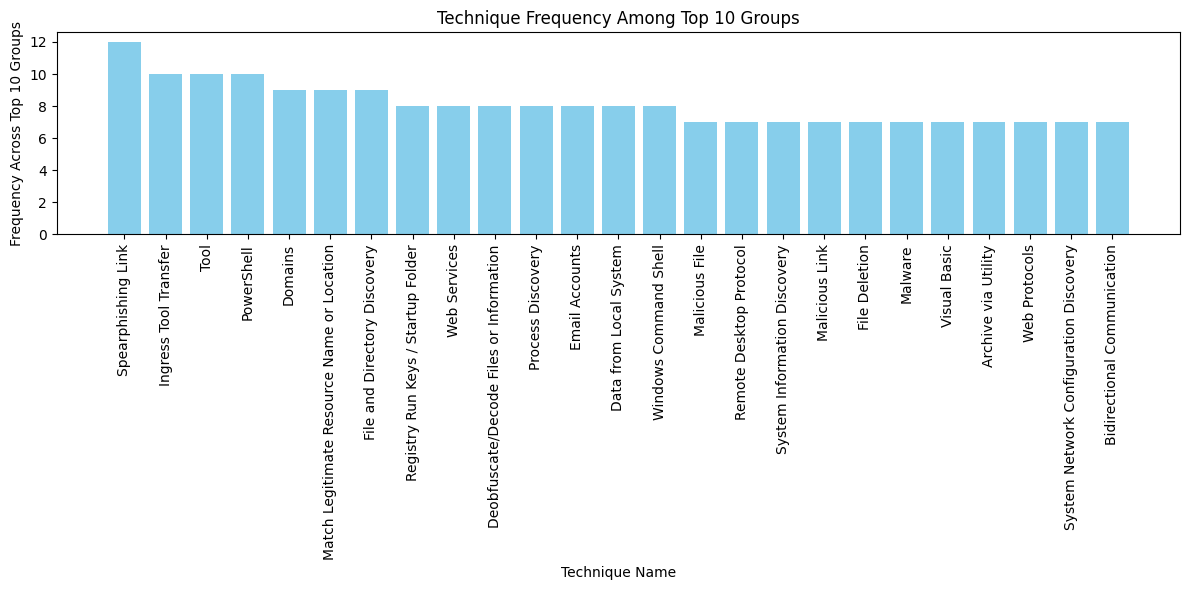

Techniques used by top 10 groups:
                                               group_id    group_name  \
2792  intrusion-set--bef4c620-0787-42a8-a96d-b7eb6e8...         APT28   
3753  intrusion-set--bef4c620-0787-42a8-a96d-b7eb6e8...         APT28   
3779  intrusion-set--bef4c620-0787-42a8-a96d-b7eb6e8...         APT28   
539   intrusion-set--bef4c620-0787-42a8-a96d-b7eb6e8...         APT28   
1248  intrusion-set--bef4c620-0787-42a8-a96d-b7eb6e8...         APT28   
...                                                 ...           ...   
655   intrusion-set--174279b4-399f-4ddb-966e-5efedd1...  Volt Typhoon   
2986  intrusion-set--174279b4-399f-4ddb-966e-5efedd1...  Volt Typhoon   
3686  intrusion-set--174279b4-399f-4ddb-966e-5efedd1...  Volt Typhoon   
3806  intrusion-set--174279b4-399f-4ddb-966e-5efedd1...  Volt Typhoon   
1069  intrusion-set--174279b4-399f-4ddb-966e-5efedd1...  Volt Typhoon   

                                           technique_id  \
2792  attack-pattern--54b4c251

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Top 10 groups from result_df
# ------------------------------------------------------------
# Replace 'score_column' with the actual column you want to rank by
top10_groups = (
    result_df
    .sort_values("final_unequal_weighting_score", ascending=False)
    .head(10)["group_name"]
)

# ------------------------------------------------------------
# 2. Get techniques for top 10 groups
# ------------------------------------------------------------
top10_group_techniques = group_techniques_df[
    group_techniques_df["group_name"].isin(top10_groups)
].copy()

# ------------------------------------------------------------
# 3. Count technique frequencies among top 10 groups
# ------------------------------------------------------------
# Make sure this column matches your actual technique column name
tech_col = "technique_name"  # change if your df uses a different name

technique_counts = (
    top10_group_techniques[tech_col]
        .value_counts()
        .reset_index()
)

technique_counts = technique_counts.head(25)
# Rename columns for clarity
technique_counts.columns = ["technique_name", "count"]

# ------------------------------------------------------------
# 4. Plot frequency of techniques
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.bar(technique_counts["technique_name"], technique_counts["count"], color='skyblue')
plt.xticks(rotation=90)
plt.xlabel("Technique Name")
plt.ylabel("Frequency Across Top 10 Groups")
plt.title("Technique Frequency Among Top 10 Groups")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Optional: print top 10 groups with their techniques
# ------------------------------------------------------------
print("Techniques used by top 10 groups:")
print(top10_group_techniques.sort_values("group_name"))

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Top 10 groups from result_df
# ------------------------------------------------------------
# Replace 'score_column' with the actual column you want to rank by
top10_groups = (
    result_df
    .sort_values("final_unequal_weighting_score", ascending=False)
    .head(10)["group_name"]
)

# ------------------------------------------------------------
# 2. Get techniques for top 10 groups
# ------------------------------------------------------------
top10_group_techniques = group_techniques_df[
    group_techniques_df["group_name"].isin(top10_groups)
].copy()

# ------------------------------------------------------------
# 3. Count technique frequencies among top 10 groups
# ------------------------------------------------------------
# Make sure this column matches your actual technique column name
tech_col = "technique_name"  # change if your df uses a different name

technique_counts = (
    top10_group_techniques[tech_col]
        .value_counts()
        .reset_index()
)


In [47]:
technique_counts

,technique_name,count
0,Spearphishing Link,12
1,Ingress Tool Transfer,10
2,Tool,10
3,PowerShell,10
4,Domains,9
...,...,...
303,Input Injection,1
304,Network Denial of Service,1
305,Botnet,1
306,Gather Victim Host Information,1
